# German Electricity Demand Forecasting

## Part 3: Benchmark Forecasting Models

This notebook implements several benchmark forecasting methods for weekly German electricity demand. These models provide baseline performance against which more advanced forecasting methods such as ARMA, SARIMA, SARIMAX, feature-based regression and LSTM will be compared.

In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings("ignore")

## Load Weekly Electricity Demand

The processed weekly electricity demand series is loaded and divided into training and testing datasets. The final two years (104 weeks) are reserved for forecast evaluation.

In [4]:
# Load weekly electricity demand

weekly_load = pd.read_csv(
    "/data/processed/weekly_load.csv",
    parse_dates=["timestamp"],
    index_col="timestamp"
)

weekly_load.head()

,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


In [5]:
# Split into training and testing data

forecast_horizon = 104

train = weekly_load.iloc[:-forecast_horizon]

test = weekly_load.iloc[-forecast_horizon:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 197
Testing observations: 104


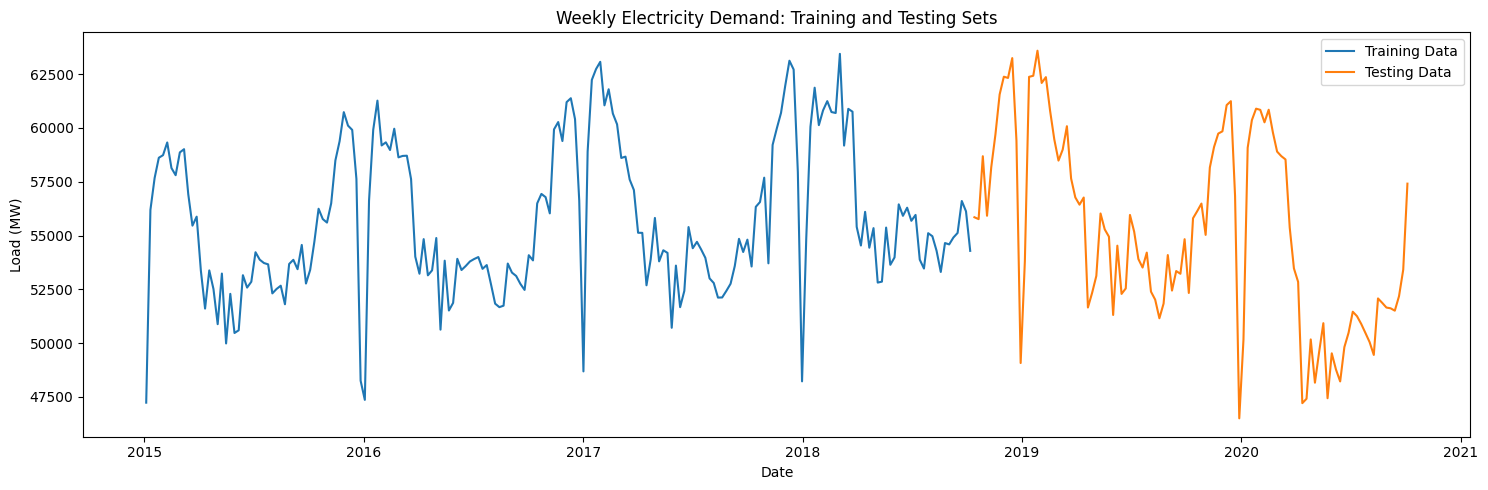

In [6]:
# Plot training and testing datasets

plt.figure(figsize=(15,5))

plt.plot(
    train.index,
    train["load"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["load"],
    label="Testing Data"
)

plt.title("Weekly Electricity Demand: Training and Testing Sets")

plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.legend()

plt.tight_layout()

plt.savefig(
    "train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()